In [1]:
import numpy as np
import numpy as np
from jax import config
import sax
from simphony.libraries import siepic, sipann
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial

# we are on notebook, so enable interactive mode for plotting
plt.ion()

config.update("jax_enable_x64", True)

/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/comp.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1780641915.268184   24514 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780641916.599496   24514 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_GAP/model
INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_STRAIGHT/model


/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/import_nn.py:125: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_ = pickle.load(file)
E0000 00:00:1780641917.329835   24514 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


INFO:tensorflow:Restoring parameters from /home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/ANN/TIGHT_ANGLE_BENT_RAND/model


/home/juanjo/Projects/PD-PiC-Design/venv/lib/python3.12/site-packages/SiPANN/import_nn.py:286: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict_ = pickle.load(file)


In [6]:
circuit, info = sax.circuit(
    netlist={
        "instances": {
            "ring_up": "half_ring",
            "ring_down": "half_ring",
        },
        "connections": {
            "ring_up,o1": "ring_down,o3",
            "ring_down,o1": "ring_up,o3",
        },
        "ports": {
            "in": "ring_up,o0",
            "through": "ring_up,o2",  # through port
            "drop": "ring_down,o2", # drop port
            "add": "ring_down,o0",  # add port
        }
    },
    models={
        "half_ring": partial(sipann.half_ring, width=500, thickness=220, gap=100),
    }
)

In [7]:
wls = np.linspace(1.55, 1.6, 100)
S = circuit(wl=wls, ring_up={"radius": 5}, ring_down={"radius": 5})

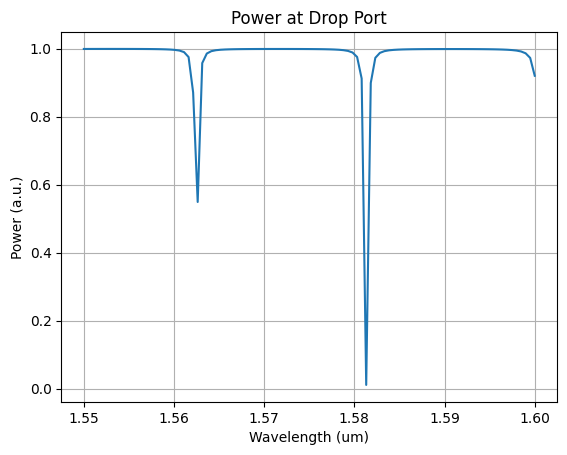

In [9]:
power = jnp.abs(S["through","in"])**2
plt.figure()
plt.plot(wls, power)
plt.xlabel("Wavelength (um)")
plt.ylabel("Power (a.u.)")
plt.title("Power at Drop Port")
plt.grid()